In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
import pandas as pd
import numpy as np

# 1. Chargement du dataset original
# Assure-toi que le fichier 'online_retail_II.xlsx' est dans le même dossier
print("Chargement des données en cours...")
df_raw = pd.read_excel('online_retail_II.xlsx')

# 2. Configuration des villes marocaines avec leurs poids (Importance commerciale)
villes_marocaines = {
    'Casablanca': 0.25,  # Plus gros volume
    'Rabat': 0.20,
    'Marrakech': 0.20,
    'Tanger': 0.15,
    'Agadir': 0.08,
    'Fès': 0.07,
    'Kenitra': 0.05,
    'Meknès': 0.05,
    'Oujda': 0.04,
    'Tétouan': 0.03,
    'El Jadida': 0.03
}

villes = list(villes_marocaines.keys())
poids = list(villes_marocaines.values())

# Ajustement des poids pour qu'ils somment exactement à 1
poids = np.array(poids)
poids /= poids.sum()

# 3. Remplacer la colonne 'Country' par des villes marocaines de manière aléatoire pondérée
print("Transformation des localisations...")
df_raw['Country'] = np.random.choice(villes, size=len(df_raw), p=poids)

# Renommer la colonne en 'City'
df_raw.rename(columns={'Country': 'City'}, inplace=True)

# 4. Sauvegarde du nouveau dataset transformé
df_raw.to_excel('marjane_data_villes.xlsx', index=False)

print("Le fichier 'content/marjane_data_villes.xlsx' a été généré avec Succès !")
df_raw.head()

Chargement des données en cours...
Transformation des localisations...
Le fichier 'content/marjane_data_villes.xlsx' a été généré avec Succès !


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,City
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,Casablanca
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,Rabat
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,Tanger
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,Casablanca
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,Rabat


In [2]:
# Chargement du nouveau fichier
df = pd.read_excel('marjane_data_villes.xlsx')

# Nettoyage
df = df.dropna(subset=['Customer ID']) # Enlever les clients sans ID
df = df[df['Quantity'] > 0]            # Enlever les retours/annulations
df['TotalAmount'] = df['Quantity'] * df['Price'] # Calcul du montant

print(f"Nettoyage terminé. Nombre de lignes prêtes : {len(df)}")

Nettoyage terminé. Nombre de lignes prêtes : 793380


In [3]:
import datetime as dt

# 1. Fixer la date d'analyse (on prend le jour après la dernière transaction)
derniere_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# 2. Création de la table RFM
# On groupe par Client et on calcule :
# - Recency : Nombre de jours depuis le dernier achat
# - Frequency : Nombre de factures uniques
# - Monetary : Somme totale dépensée
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (derniere_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum',
    'City': 'first' # On garde la ville pour les analyses futures
})

# 3. Renommer les colonnes
rfm.columns = ['Recency', 'Frequency', 'Monetary', 'City']

# 4. Supprimer les clients avec un montant nul ou négatif (si restants)
rfm = rfm[rfm['Monetary'] > 0]

print("Table RFM générée avec succès !")
rfm.head()

Table RFM générée avec succès !


,Recency,Frequency,Monetary,City
Customer ID,,,,
12346.0,321,12,77556.46,Kenitra
12347.0,35,7,5408.50,Rabat
12348.0,71,5,2019.40,Kenitra
12349.0,14,4,4428.69,Oujda
12350.0,305,1,334.40,Marrakech


In [4]:
# Création des scores par quartiles
# q=4 divise les données en 4 parts égales
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[1, 2, 3, 4])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method="first"), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Combiner les scores en un seul identifiant RFM
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,City,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,,
12346.0,321,12,77556.46,Kenitra,3,4,4,344
12347.0,35,7,5408.50,Rabat,2,3,4,234
12348.0,71,5,2019.40,Kenitra,2,3,3,233
12349.0,14,4,4428.69,Oujda,1,3,4,134
12350.0,305,1,334.40,Marrakech,3,1,1,311


In [5]:
# 1. On garde l'index ou une copie des ID
customer_ids = rfm.index

# 2. On crée un nouveau tableau avec UNIQUEMENT les colonnes à calculer
# On exclut 'City' et 'Customer ID' (s'il est dans les colonnes)
rfm_to_scale = rfm[['Recency', 'Frequency', 'Monetary']]

# 3. On applique la standardisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_to_scale)

# 4. On reconstruit un DataFrame avec les ID pour ne pas les perdre
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=customer_ids, columns=rfm_to_scale.columns)
rfm_scaled_df.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.578473,0.449237,5.198186
12347.0,-0.800021,0.060500,0.170859
12348.0,-0.626504,-0.094995,-0.065296
12349.0,-0.901239,-0.172742,0.102585
12350.0,0.501354,-0.405985,-0.182708


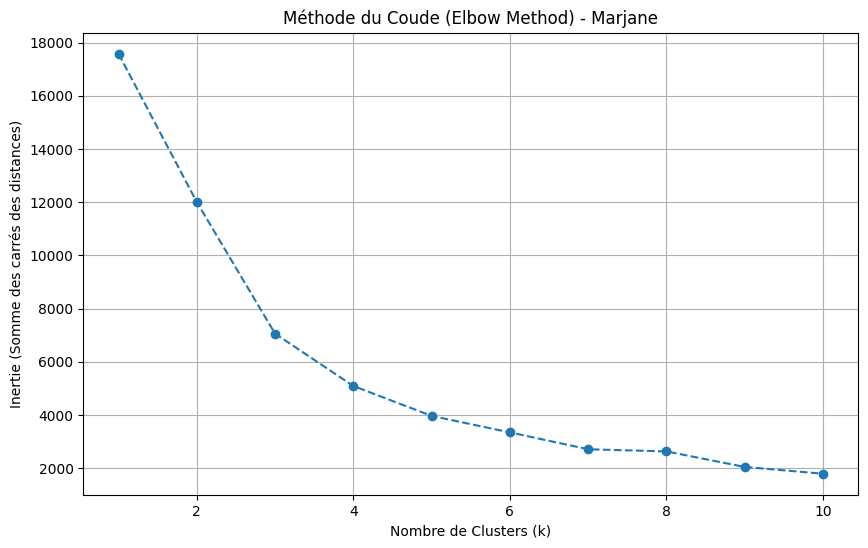

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. On prépare une liste pour stocker l'inertie
sse = []

# 2. On teste de 1 à 10 clusters
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled_df) # On utilise les données standardisées
    sse.append(kmeans.inertia_)

# 3. Traçage du graphique
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o', linestyle='--')
plt.title('Méthode du Coude (Elbow Method) - Marjane')
plt.xlabel('Nombre de Clusters (k)')
plt.ylabel('Inertie (Somme des carrés des distances)')
plt.grid(True)
plt.show()

In [7]:
# 1. Application du K-Means avec 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

# 2. Vérifier la taille de chaque groupe
print(rfm['Cluster'].value_counts())

# 3. Afficher les premières lignes avec le cluster
rfm.head()

Cluster
2    3821
0    1998
1      37
3       4
Name: count, dtype: int64


,Recency,Frequency,Monetary,City,R_Score,F_Score,M_Score,RFM_Score,Cluster
Customer ID,,,,,,,,,
12346.0,321,12,77556.46,Kenitra,3,4,4,344,2
12347.0,35,7,5408.50,Rabat,2,3,4,234,2
12348.0,71,5,2019.40,Kenitra,2,3,3,233,2
12349.0,14,4,4428.69,Oujda,1,3,4,134,2
12350.0,305,1,334.40,Marrakech,3,1,1,311,0


In [8]:
# Création d'un dictionnaire de correspondance
cluster_names = {
    1: "VIP / Champions",
    0: "Clients Réguliers",
    2: "Clients à Risque / Perdus",
    3: "Gros Acheteurs Occasionnels"
}

# Application des noms
rfm['Segment_Name'] = rfm['Cluster'].map(cluster_names)

# Vérification
rfm[['Recency', 'Frequency', 'Monetary', 'Segment_Name']].head()

,Recency,Frequency,Monetary,Segment_Name
Customer ID,,,,
12346.0,321,12,77556.46,Clients à Risque / Perdus
12347.0,35,7,5408.50,Clients à Risque / Perdus
12348.0,71,5,2019.40,Clients à Risque / Perdus
12349.0,14,4,4428.69,Clients à Risque / Perdus
12350.0,305,1,334.40,Clients Réguliers


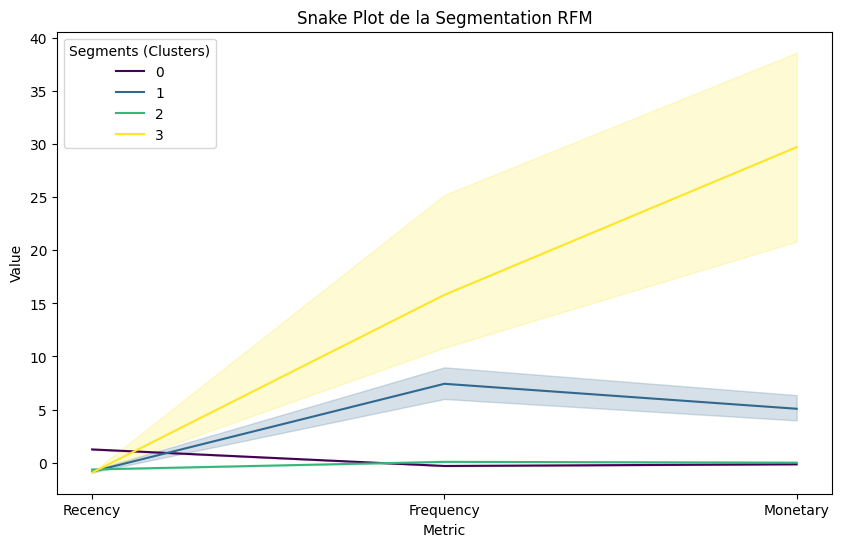

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Add the 'Cluster' column from the original rfm DataFrame to rfm_scaled_df
rfm_scaled_df_with_cluster = rfm_scaled_df.copy()
rfm_scaled_df_with_cluster['Cluster'] = rfm['Cluster']

# 1. Préparation des données pour le graphique
rfm_melted = pd.melt(rfm_scaled_df_with_cluster.reset_index(),
                    id_vars=['Customer ID', 'Cluster'],
                    value_vars=['Recency', 'Frequency', 'Monetary'],
                    var_name='Metric',
                    value_name='Value')

# 2. Création du Snake Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='Metric', y='Value', hue='Cluster', data=rfm_melted, palette='viridis')
plt.title('Snake Plot de la Segmentation RFM')
plt.legend(title='Segments (Clusters)')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Définition de la cible (Churn)
# On considère un client comme "parti" s'il n'est pas venu depuis plus de 90 jours
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)

# 2. Sélection des variables prédictives (X) et de la cible (y)
# On utilise les scores RFM et le Cluster comme variables d'entrée
X = rfm[['Recency', 'Frequency', 'Monetary', 'Cluster']]
y = rfm['Churn']

# 3. Division en Train (80%) et Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Données prêtes pour l'entraînement !")

Données prêtes pour l'entraînement !


In [12]:
# --- MODÈLE 1 : RÉGRESSION LOGISTIQUE ---
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# --- MODÈLE 2 : RANDOM FOREST ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Affichage des résultats
print("--- RÉSULTATS RÉGRESSION LOGISTIQUE ---")
print(classification_report(y_test, y_pred_log))

print("\n--- RÉSULTATS RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- RÉSULTATS RÉGRESSION LOGISTIQUE ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       569
           1       1.00      1.00      1.00       603

    accuracy                           1.00      1172
   macro avg       1.00      1.00      1.00      1172
weighted avg       1.00      1.00      1.00      1172


--- RÉSULTATS RANDOM FOREST ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       569
           1       1.00      1.00      1.00       603

    accuracy                           1.00      1172
   macro avg       1.00      1.00      1.00      1172
weighted avg       1.00      1.00      1.00      1172



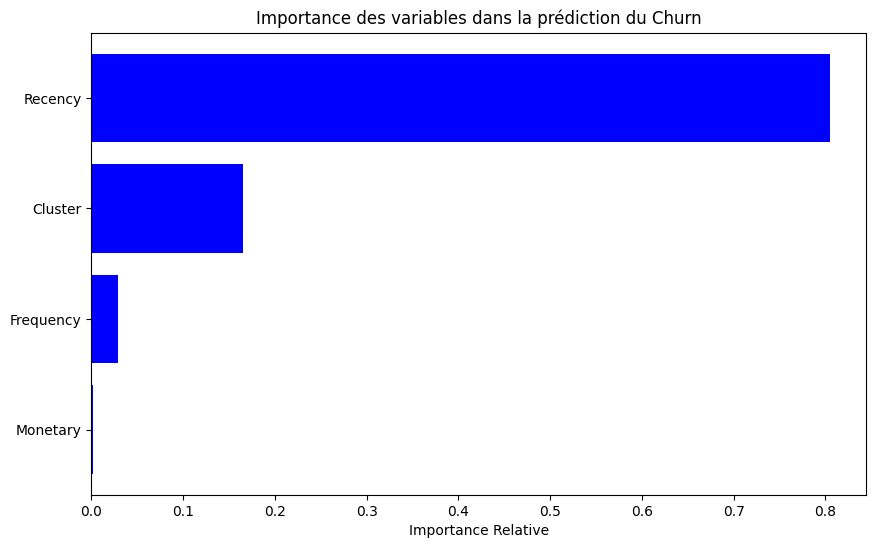

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Récupération de l'importance des variables
importances = rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)

# Création du graphique
plt.figure(figsize=(10, 6))
plt.title('Importance des variables dans la prédiction du Churn')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importance Relative')
plt.show()